# 08j — Evidence-tiered multi-objective ranking

This notebook integrates Pipeline 4 without treating missing expensive evaluations as favourable values. It produces separate rankings for: (1) all 24 ProteinMPNN designs using common AI/CamSol evidence; (2) the five 08d candidates using real structural evidence; and (3) the two fully evaluated new leads using 08f endpoint, 08g ESMFold, 08e MD, 08d structure and authentic CamSol.

Scores are transparent decision-support summaries, not binding free energies or experimental predictions.

In [1]:
from pathlib import Path
import json, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

root_candidates=[Path(os.environ.get("PEARL_ROOT","")),Path.cwd(),Path('/Users/robertobruzzese/Desktop/venv')]
ROOT=next((p for p in root_candidates if (p/'outputs/pipeline_4_ai_08b_proteinmpnn').exists()),None)
if ROOT is None: raise FileNotFoundError("PEARL root not found; set PEARL_ROOT")
OUTPUT_ROOT=ROOT/"outputs/pipeline_4_ai_08j_final_multiobjective"
TABLE_DIR,FIGURE_DIR,PROVENANCE_DIR=(OUTPUT_ROOT/x for x in ("tables","figures","provenance"))
for d in (TABLE_DIR,FIGURE_DIR,PROVENANCE_DIR): d.mkdir(parents=True,exist_ok=True)
P08I=ROOT/"outputs/pipeline_4_ai_08i_bayesian_optimisation/tables/08i_discrete_acquisition_ranking.csv"
P08B=ROOT/"outputs/pipeline_4_ai_08b_proteinmpnn/production/tables/08b_ProteinMPNN_unique_designs.csv"
P08C=ROOT/"outputs/pipeline_4_ai_08c_integrated_candidate_selection/tables/08c_ESM2_all_sequence_scores.csv"
P08D=ROOT/"outputs/pipeline_4_ai_08d_structural_validation/tables/08d_integrated_structural_ranking.csv"
P08F=ROOT/"outputs/pipeline_4_ai_08f_endpoint_energy/production_50snap/tables/08f_ProteinMPNN_cross_method_evidence.csv"
P08G=ROOT/"outputs/pipeline_4_ai_08g_esmfold_structural_validation/tables/08g_ESMFold_structural_validation_summary.csv"
P08H=ROOT/"outputs/pipeline_4_ai_08h_solubility_developability/tables/08h_solubility_developability_summary.csv"
for p in (P08I,P08B,P08C,P08D,P08F,P08G,P08H):
    if not p.exists(): raise FileNotFoundError(p)

def z(s,higher=True):
    s=pd.to_numeric(s,errors="raise"); sd=s.std(ddof=0); out=(s-s.mean())/(sd if sd>0 else 1)
    return out if higher else -out
def rank_score(df, specs, weights):
    parts=[]
    for col,higher in specs.items():
        name=col+"_oriented_z"; df[name]=z(df[col],higher); parts.append(weights[col]*df[name])
    df["composite_score"]=sum(parts); df["rank"]=df.composite_score.rank(ascending=False,method="min").astype(int)
    return df.sort_values(["rank"]).reset_index(drop=True)

## Tier 1 — Full 24-design screening

All candidates have ProteinMPNN, ESM-2 and validated CamSol. Equal weights are used. This tier prioritizes hypotheses for additional structural evaluation.

In [2]:
b=pd.read_csv(P08B).rename(columns={"peptide_sequence":"sequence"}); b["candidate_id"]=b.ProteinMPNN_rank.map(lambda x:f"MPNN_POOL_{int(x):03d}")
c=pd.read_csv(P08C); c=c[c.source.astype(str).str.startswith("ProteinMPNN")][["sequence","ESM2_PLL_mean"]]
h=pd.read_csv(P08H)[["candidate_id","sequence","camsol_overall_score","camsol_result_validated"]]
t1=b.merge(c,on="sequence",validate="one_to_one").merge(h,on=["candidate_id","sequence"],validate="one_to_one")
t1=rank_score(t1,{"best_ProteinMPNN_score":False,"ESM2_PLL_mean":True,"camsol_overall_score":True},{"best_ProteinMPNN_score":1/3,"ESM2_PLL_mean":1/3,"camsol_overall_score":1/3})
t1.rename(columns={"rank":"screening_rank","composite_score":"screening_score"},inplace=True)
t1.to_csv(TABLE_DIR/"08j_tier1_full_pool_screening.csv",index=False)
display(t1[["screening_rank","candidate_id","sequence","best_ProteinMPNN_score","ESM2_PLL_mean","camsol_overall_score","screening_score"]].head(10))

,screening_rank,candidate_id,sequence,best_ProteinMPNN_score,ESM2_PLL_mean,camsol_overall_score,screening_score
0,1,MPNN_POOL_016,PGPRNQYRDLP,1.4235,-3.118172,2.337157,1.057125
1,2,MPNN_POOL_001,TGPRNQYRDLP,1.2473,-3.172003,2.185477,0.566547
2,3,MPNN_POOL_003,TGPRNQYRDLG,1.2572,-3.168259,2.172541,0.548265
3,4,MPNN_POOL_007,TGPRNQYRDLS,1.3576,-3.141671,2.166626,0.544806
4,5,MPNN_POOL_004,VGPRNQYRDLP,1.2978,-3.139989,2.052727,0.458195
5,6,MPNN_POOL_011,TGPRHQYRDLP,1.3882,-3.126106,2.072265,0.398075
6,7,MPNN_POOL_012,VGPRNQYRDLG,1.3965,-3.122553,2.039790,0.332834
7,8,MPNN_POOL_017,VGPRNQYRDLS,1.4355,-3.118249,2.033875,0.250388
8,9,MPNN_POOL_002,TGPRNQYRDLN,1.2479,-3.200399,2.184338,0.222800
9,10,MPNN_POOL_009,TGPRNQYRDLT,1.3831,-3.161015,2.133869,0.153077


## Tier 2 — Five structurally validated candidates

The structural objective combines real FoldX and Rosetta observations (50%). AI integrated evidence contributes 25%, and CamSol contributes 25%.

In [3]:
d=pd.read_csv(P08D); cam=pd.read_csv(P08H)[["sequence","camsol_overall_score"]]
t2=d.merge(cam,left_on="peptide_sequence",right_on="sequence",validate="one_to_one")
t2["structural_combined"]=0.5*z(t2.foldx_interaction_energy_kcal_mol,False)+0.5*z(t2.best_I_sc,False)
t2["structural_oriented_z"]=z(t2.structural_combined,True); t2["AI_oriented_z"]=z(t2.AI_integrated_score,True); t2["CamSol_oriented_z"]=z(t2.camsol_overall_score,True)
t2["tier2_score"]=0.50*t2.structural_oriented_z+0.25*t2.AI_oriented_z+0.25*t2.CamSol_oriented_z
t2["tier2_rank"]=t2.tier2_score.rank(ascending=False,method="min").astype(int); t2=t2.sort_values("tier2_rank")
t2.to_csv(TABLE_DIR/"08j_tier2_structurally_validated.csv",index=False)
display(t2[["tier2_rank","candidate_id","peptide_sequence","foldx_interaction_energy_kcal_mol","best_I_sc","camsol_overall_score","tier2_score"]])

,tier2_rank,candidate_id,peptide_sequence,foldx_interaction_energy_kcal_mol,best_I_sc,camsol_overall_score,tier2_score
1,1,MPNN_NEW_01,TGPRNQYRDLP,-11.74070,-54.169,2.185477,0.493248
0,2,MPNN_NEW_05,IGPRHQYRDLP,-13.74780,-56.118,1.981126,0.426804
2,3,MPNN_NEW_02,IGPRNQYRDLG,-12.70790,-53.354,2.064671,0.086265
3,4,MPNN_NEW_04,IGPRNQYRDLN,-11.30780,-53.920,2.076468,-0.180192
4,5,MPNN_NEW_03,PGPRNQYRDLP,-9.44251,-51.556,2.337157,-0.826126


## Tier 3 — Two fully evaluated new candidate peptides

Only NEW01 and NEW05 have all five computational evidence classes used here: static structure, MD stability, endpoint energy, ESMFold confidence and CamSol prediction. Each class receives equal weight in this decision-support summary. These computational criteria are complementary and are not assumed to constitute statistically or experimentally independent evidence. With only two candidates, standardized components are directional contrasts, not calibrated effect sizes.

In [4]:
f=pd.read_csv(P08F); g=pd.read_csv(P08G)[["candidate_id","mean_pLDDT"]]; cam=pd.read_csv(P08H)[["sequence","camsol_overall_score"]]
t3=f.merge(g,on="candidate_id",validate="one_to_one").merge(cam,on="sequence",validate="one_to_one")
t3["static_structure_component"]=0.5*z(t3.foldx_interaction_energy_kcal_mol,False)+0.5*z(t3.best_I_sc,False)
t3["md_component"]=0.5*z(t3.mean_peptide_CA_RMSD_A,False)+0.5*z(t3.mean_contact_persistence,True)
spec={"static_structure_component":True,"md_component":True,"mean_delta_E_endpoint_kcal_mol":False,"mean_pLDDT":True,"camsol_overall_score":True}
for col,higher in spec.items(): t3[col+"_z"]=z(t3[col],higher)
t3["tier3_score"]=sum(t3[col+"_z"] for col in spec)/len(spec)
t3["tier3_rank"]=t3.tier3_score.rank(ascending=False,method="min").astype(int); t3=t3.sort_values("tier3_rank")
t3.to_csv(TABLE_DIR/"08j_tier3_fully_evaluated_new_leads.csv",index=False)
display(t3[["tier3_rank","candidate_id","sequence","mean_delta_E_endpoint_kcal_mol","mean_pLDDT","camsol_overall_score","tier3_score"]])

,tier3_rank,candidate_id,sequence,mean_delta_E_endpoint_kcal_mol,mean_pLDDT,camsol_overall_score,tier3_score
0,1,MPNN_NEW_01,TGPRNQYRDLP,-46.408438,72.559091,2.185477,0.2
1,2,MPNN_NEW_05,IGPRHQYRDLP,-53.673748,67.273636,1.981126,-0.2


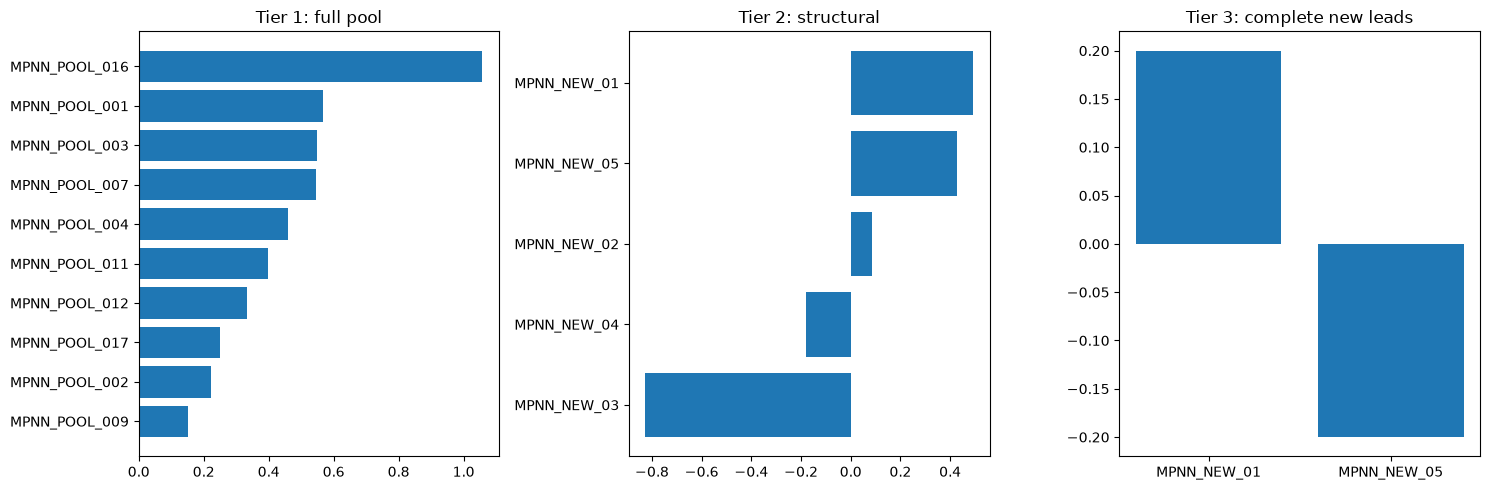

,check,pass
0,tier1_has_24_designs,True
1,tier1_camsol_validated,True
2,tier2_has_5_real_structural_candidates,True
3,tier3_has_2_complete_new_leads,True
4,no_missing_values_in_rank_components,True


ALL QC PASSED: True


541

In [5]:
coverage=t1[["candidate_id","sequence"]].copy(); coverage["AI_ProteinMPNN_ESM2"]=True; coverage["CamSol"]=True
coverage["FoldX_Rosetta"]=coverage.sequence.isin(set(t2.peptide_sequence)); coverage["MD_endpoint_ESMFold"]=coverage.sequence.isin(set(t3.sequence))
coverage.to_csv(TABLE_DIR/"08j_evidence_coverage.csv",index=False)

fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].barh(t1.head(10).candidate_id[::-1],t1.head(10).screening_score[::-1]); axes[0].set_title("Tier 1: full pool")
axes[1].barh(t2.candidate_id[::-1],t2.tier2_score[::-1]); axes[1].set_title("Tier 2: structural")
axes[2].bar(t3.candidate_id,t3.tier3_score); axes[2].set_title("Tier 3: complete new leads")
fig.tight_layout(); fig.savefig(FIGURE_DIR/"08j_evidence_tier_rankings.png",dpi=220); plt.show()

qc=pd.DataFrame([
 {"check":"tier1_has_24_designs","pass":len(t1)==24},
 {"check":"tier1_camsol_validated","pass":bool(t1.camsol_result_validated.all())},
 {"check":"tier2_has_5_real_structural_candidates","pass":len(t2)==5},
 {"check":"tier3_has_2_complete_new_leads","pass":len(t3)==2},
 {"check":"no_missing_values_in_rank_components","pass":not (t1[["best_ProteinMPNN_score","ESM2_PLL_mean","camsol_overall_score"]].isna().any().any() or t2[["foldx_interaction_energy_kcal_mol","best_I_sc","camsol_overall_score"]].isna().any().any() or t3[["mean_delta_E_endpoint_kcal_mol","mean_pLDDT","camsol_overall_score"]].isna().any().any())},
])
qc.to_csv(TABLE_DIR/"08j_QC.csv",index=False); display(qc); print("ALL QC PASSED:",bool(qc["pass"].all()))
prov={"ranking_policy":"separate evidence-complete tiers; no favourable imputation","tier1_weights":{"ProteinMPNN":1/3,"ESM2":1/3,"CamSol":1/3},"tier2_weights":{"FoldX_Rosetta":0.5,"AI":0.25,"CamSol":0.25},"tier3_weights":{"FoldX_Rosetta":0.2,"MD":0.2,"endpoint":0.2,"ESMFold":0.2,"CamSol":0.2},"interpretation":"decision support; not affinity, experimental solubility, or validated therapeutic ranking"}
(PROVENANCE_DIR/"08j_provenance.json").write_text(json.dumps(prov,indent=2)+"\n")